<a href="https://colab.research.google.com/github/ssleona67/Integracion-de-datos-y-prospectiva/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Para reproducibilidad
np.random.seed(42)
num_datos=100

# Paso 1: Generar datos aleatorios simulados
ventas = np.random.normal(loc=500000, scale=20000, size=num_datos).round(2)  # ventas en miles de pesos
unidades = np.random.normal(loc=1200, scale=300, size=num_datos).round(0)  # unidades vendidas

# Crear DataFrame
df = pd.DataFrame({
    'unidades': unidades,
    'ventas': ventas
})

In [ ]:
df

,unidades,ventas
0,775.0,509934.28
1,1074.0,497234.71
2,1097.0,512953.77
3,959.0,530460.60
4,1152.0,495316.93
...,...,...
95,1316.0,470729.70
96,935.0,505922.41
97,1246.0,505221.11
98,1217.0,500102.27


In [ ]:
num_centroids = 3
initial_indices = np.random.choice(range(df.shape[0]), size=num_centroids, replace=False)
centroids = df.iloc[initial_indices]

In [ ]:
centroids

,unidades,ventas
93,826.0,493446.76
28,1230.0,487987.23
55,986.0,518625.60


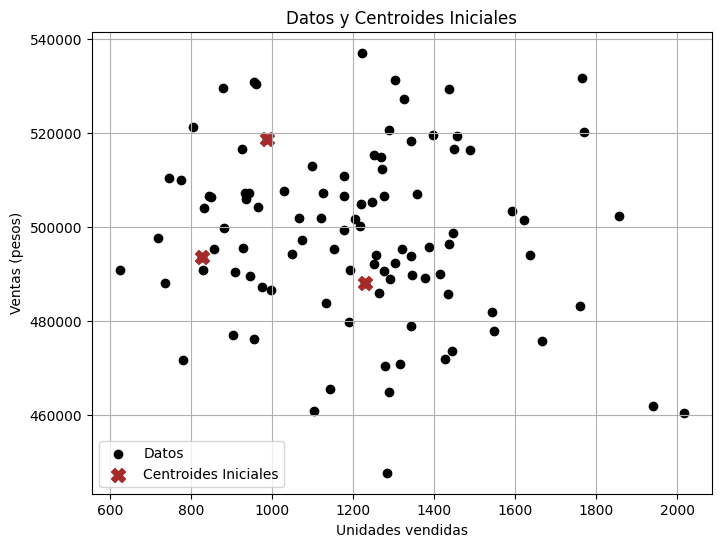

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['unidades'],df['ventas'], c='black', label='Datos')
plt.scatter(centroids['unidades'], centroids['ventas'],  c='brown', marker='X', s=100, label='Centroides Iniciales')
plt.title('Datos y Centroides Iniciales')
plt.ylabel('Ventas (pesos)')
plt.xlabel('Unidades vendidas')
plt.legend()
plt.grid(True)
plt.show()

# ¿Qué pasa cuando hacemos clustering sin escalar los datos?

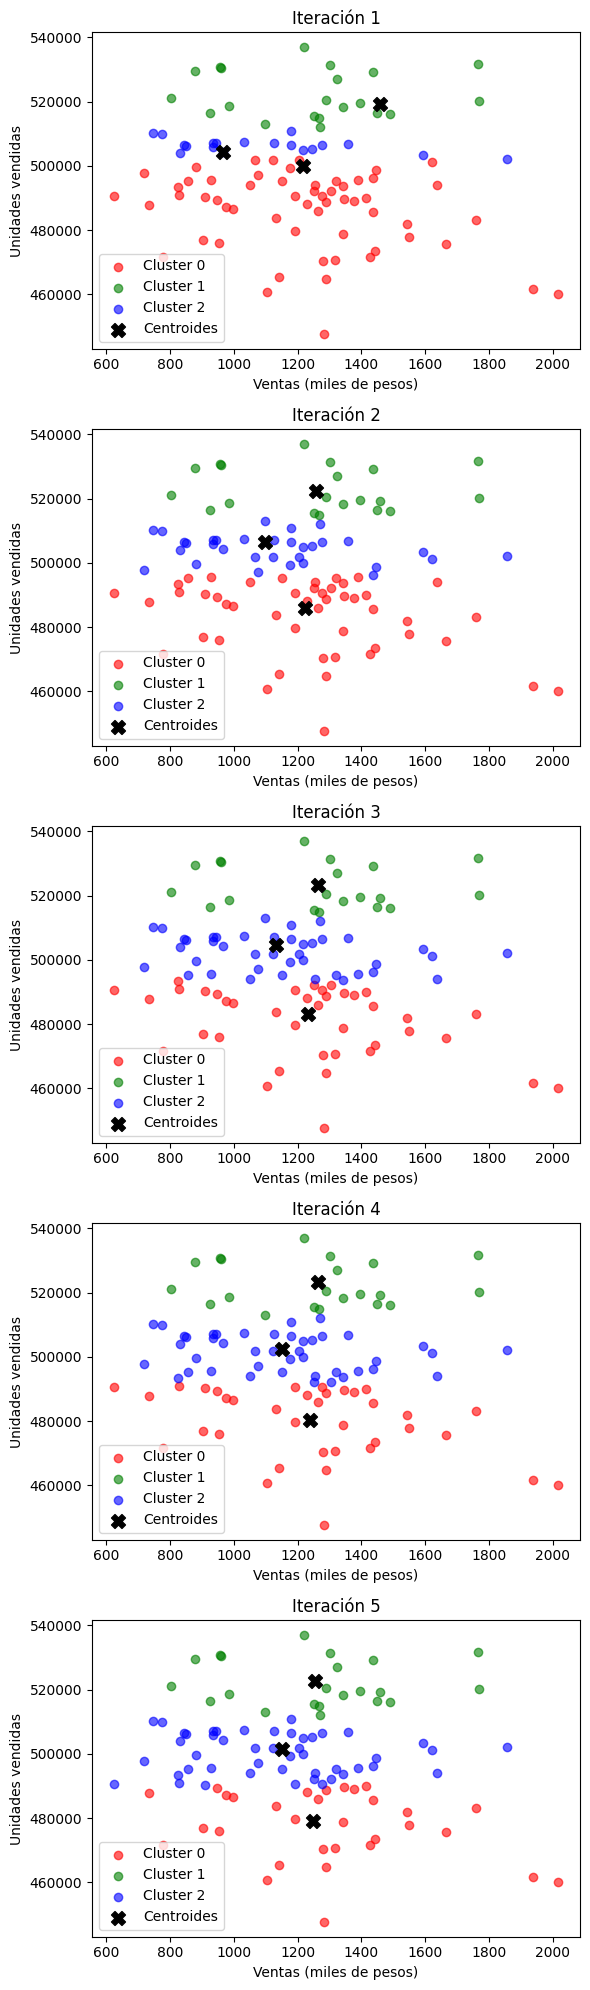

In [ ]:
# Función para calcular distancia euclidiana y asignar clusters
def assign_clusters(X, centroids):
    # Ensure X is a NumPy array
    if isinstance(X, pd.DataFrame):
        X = X.values
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

X_raw = df.values  # ventas y unidades sin escalar

# Inicializar 3 centroides aleatorios tomados de los datos existentes
initial_indices_raw = np.random.choice(range(X_raw.shape[0]), size=3, replace=False)
centroids_raw = X_raw[initial_indices_raw]

# Almacenar la evolución de los clusters para graficar cada iteración
cluster_history_raw = []

# Ejecutar el algoritmo K-means manualmente sobre datos no escalados
centroids = centroids_raw.copy()
max_iters = 5
for iteration in range(max_iters):
    # Asignar puntos al centroide más cercano
    labels = assign_clusters(X_raw, centroids)

    # Guardar asignaciones para graficar
    cluster_history_raw.append((centroids.copy(), labels.copy()))

    # Recalcular centroides
    new_centroids = np.array([
        X_raw[labels == i].mean(axis=0) if len(X_raw[labels == i]) > 0 else centroids[i]
        for i in range(3)
    ])

    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

# Graficar la evolución de los clusters en columnas sin escalar
fig, axes = plt.subplots(len(cluster_history_raw), 1, figsize=(6, 20))
colors = ['red', 'green', 'blue']

for i, (cents, lbls) in enumerate(cluster_history_raw):
    ax = axes[i]
    for cluster_id in range(3):
        ax.scatter(
            X_raw[lbls == cluster_id, 0],
            X_raw[lbls == cluster_id, 1],
            c=colors[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.6
        )
    ax.scatter(cents[:, 0], cents[:, 1], c='black', marker='X', s=100, label='Centroides')
    ax.set_title(f'Iteración {i+1}')
    ax.set_xlabel('Ventas (miles de pesos)')
    ax.set_ylabel('Unidades vendidas')
    ax.legend()

plt.tight_layout()
plt.show()

# Clustering escalando los datos

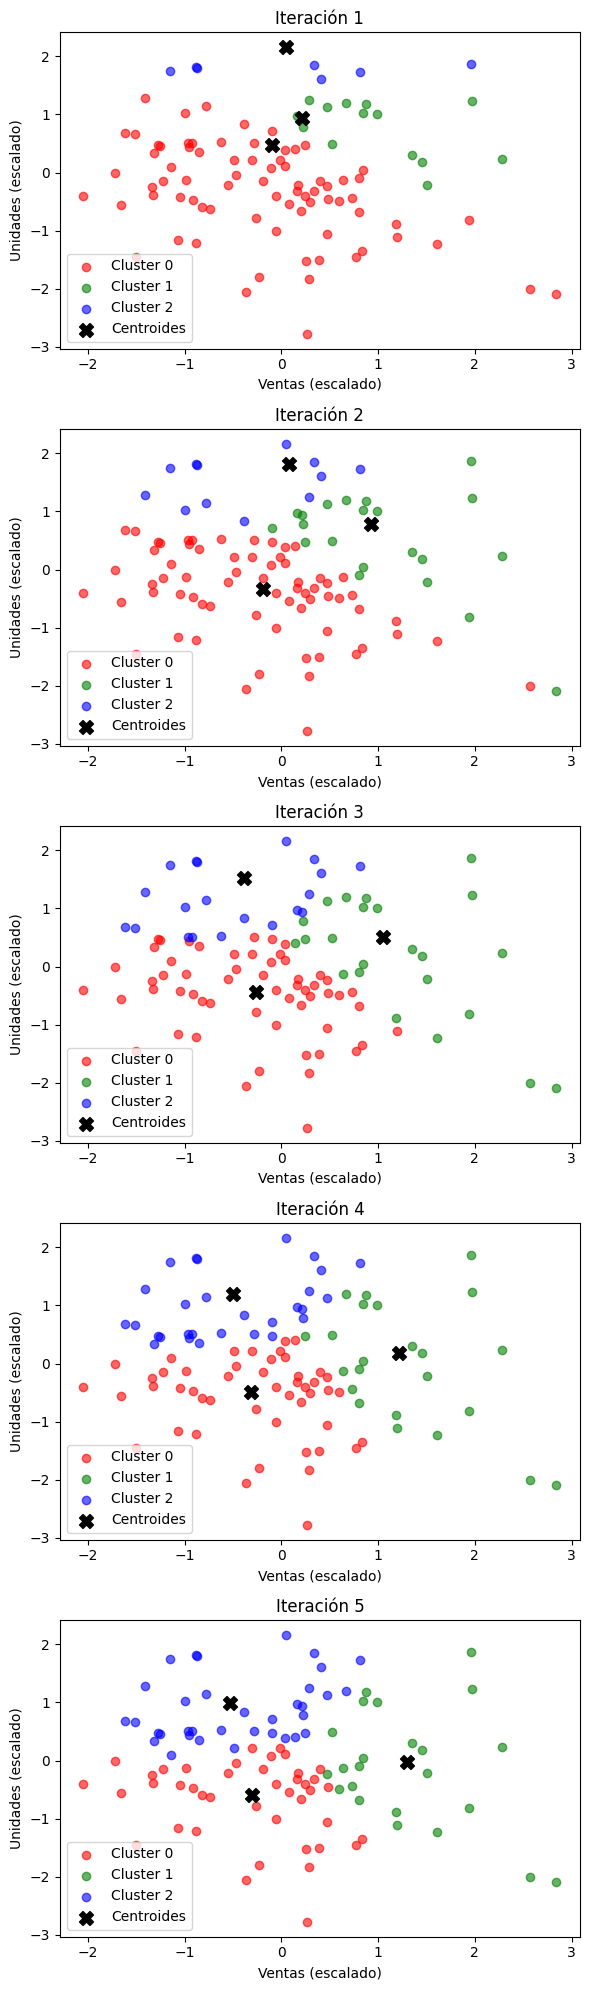

In [ ]:
# Almacenar la evolución de los clusters para graficar cada iteración
cluster_history = []

# Ejecutar el algoritmo K-means manualmente
max_iters = 5
# Convertir el DataFrame a un NumPy array
scaler = StandardScaler()
X_scaled_np = scaler.fit_transform(df)
# Inicializar 3 centroides aleatorios tomados de los datos existentes
initial_indices = np.random.choice(range(X_scaled_np.shape[0]), size=3, replace=False)
centroids = X_scaled_np[initial_indices]

for iteration in range(max_iters):
    # Asignar puntos al centroide más cercano
    labels = assign_clusters(X_scaled_np, centroids)

    # Guardar asignaciones para graficar
    cluster_history.append((centroids.copy(), labels.copy()))

    # Recalcular centroides
    new_centroids = np.array([
        X_scaled_np[labels == i].mean(axis=0) if len(X_scaled_np[labels == i]) > 0 else centroids[i]
        for i in range(3)
    ])

    # Verificar convergencia (opcional)
    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

# Graficar la evolución de los clusters
fig, axes = plt.subplots(len(cluster_history), 1, figsize=(6, 20))
colors = ['red', 'green', 'blue']

for i, (cents, lbls) in enumerate(cluster_history):
    ax = axes[i]
    for cluster_id in range(3):
        ax.scatter(
            X_scaled_np[lbls == cluster_id, 0],
            X_scaled_np[lbls == cluster_id, 1],
            c=colors[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.6
        )
    ax.scatter(cents[:, 0], cents[:, 1], c='black', marker='X', s=100, label='Centroides')
    ax.set_title(f'Iteración {i+1}')
    ax.set_xlabel('Ventas (escalado)')
    ax.set_ylabel('Unidades (escalado)')
    ax.legend()

plt.tight_layout()
plt.show()

# Clustering con `sklearn`

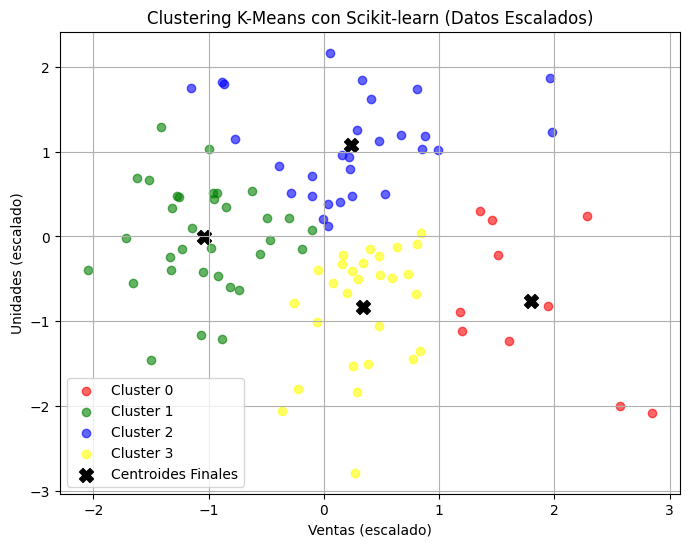

In [ ]:
from sklearn.cluster import KMeans

# Usar la implementación de KMeans de scikit-learn
X_scaled = scaler.fit_transform(df)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init='auto' es por defecto y lo recomendado
kmeans.fit(X_scaled)

# Obtener las etiquetas y los centroides finales
final_labels = kmeans.labels_
final_centroids = kmeans.cluster_centers_

# Graficar el resultado final del clustering
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue','yellow']
for cluster_id in range(4):
    plt.scatter(
        X_scaled[final_labels == cluster_id, 0],
        X_scaled[final_labels == cluster_id, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', marker='X', s=100, label='Centroides Finales')
plt.title('Clustering K-Means con Scikit-learn (Datos Escalados)')
plt.xlabel('Ventas (escalado)')
plt.ylabel('Unidades (escalado)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
original_centroids = scaler.inverse_transform(final_centroids).round(0)
original_centroids

array([[  1273., 517295.],
       [   911., 497742.],
       [  1413., 483296.]])

In [ ]:
# Invertir la transformación de los centroides para interpretarlos en la escala original
original_centroids = scaler.inverse_transform(final_centroids).round(0)

# Crear un DataFrame para mostrar los centroides en la escala original
centroids_df = pd.DataFrame(original_centroids, columns=['unidades', 'ventas'])
print("Centroides en la escala original:")
display(centroids_df)

# Añadir las etiquetas de los clusters al DataFrame original
df['cluster'] = final_labels

# Mostrar la media de cada cluster para interpretar los resultados
print("\nMedia de cada cluster:")
display(df.groupby('cluster').mean())

Centroides en la escala original:


,unidades,ventas
0,1272.586207,517295.111034
1,911.333333,497741.971818
2,1412.921053,483296.413684



Media de cada cluster:


,unidades,ventas
cluster,,
0,1272.586207,517295.111034
1,911.333333,497741.971818
2,1412.921053,483296.413684


# **Valor de n_init**

Si los datos tienen muchos clústeres o alta variabilidad, se puede subir n_init (por ejemplo, n_init=20 o n_init=50) para tener más confianza en que se encuentra una buena solución.

Si se quiere una ejecución más rápida, se puede usar un n_init bajo, pero a costa de mayor riesgo de converger a un mínimo local pobre.

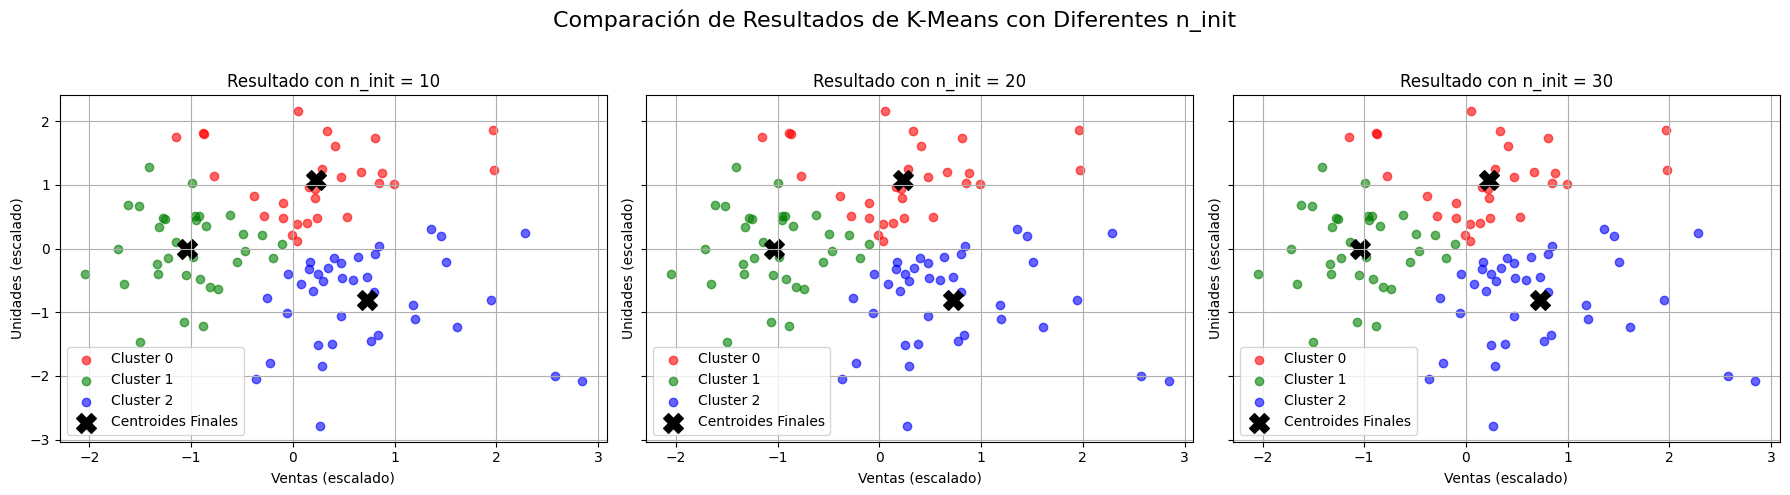

In [ ]:
# Comparar el efecto de n_init
n_init_values = [10, 20, 30]
fig, axes = plt.subplots(1, len(n_init_values), figsize=(18, 5), sharey=True)

for i, n_init in enumerate(n_init_values):
    # Entrenar el modelo con el valor actual de n_init
    kmeans = KMeans(n_clusters=3, n_init=n_init, random_state=42)
    kmeans.fit(X_scaled)
    final_labels = kmeans.labels_
    final_centroids = kmeans.cluster_centers_

    # Graficar el resultado
    ax = axes[i]
    colors = ['red', 'green', 'blue']
    for cluster_id in range(3):
        ax.scatter(
            X_scaled[final_labels == cluster_id, 0],
            X_scaled[final_labels == cluster_id, 1],
            c=colors[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.6
        )
    ax.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', marker='X', s=200, label='Centroides Finales')
    ax.set_title(f'Resultado con n_init = {n_init}')
    ax.set_xlabel('Ventas (escalado)')
    ax.set_ylabel('Unidades (escalado)')
    ax.legend()
    ax.grid(True)

plt.suptitle('Comparación de Resultados de K-Means con Diferentes n_init', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Comparar los centroides en la escala original para cada valor de n_init
n_init_values = [10, 20, 30]

for n_init in n_init_values:
    # Entrenar el modelo con el valor actual de n_init
    kmeans = KMeans(n_clusters=3, n_init=n_init, random_state=42)
    kmeans.fit(X_scaled)

    # Obtener los centroides en la escala original
    original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    # Crear un DataFrame para una visualización clara
    centroids_df = pd.DataFrame(original_centroids, columns=['unidades', 'ventas'])

    # Imprimir los resultados
    print(f"--- Centroides Originales con n_init = {n_init} ---")
    display(centroids_df)
    print("\\n")

--- Centroides Originales con n_init = 10 ---


,unidades,ventas
0,1272.586207,517295.111034
1,911.333333,497741.971818
2,1412.921053,483296.413684


\n
--- Centroides Originales con n_init = 20 ---


,unidades,ventas
0,1272.586207,517295.111034
1,911.333333,497741.971818
2,1412.921053,483296.413684


\n
--- Centroides Originales con n_init = 30 ---


,unidades,ventas
0,1272.586207,517295.111034
1,911.333333,497741.971818
2,1412.921053,483296.413684


\n


# Número optimo de clusters

K=1 - Inercia: 200.0
K=2 - Inercia: 126.51569338700136
K=3 - Inercia: 84.76734366508073
K=4 - Inercia: 67.45886532652393
K=5 - Inercia: 53.327591809686474
K=6 - Inercia: 42.02557893054153
K=7 - Inercia: 35.778878595460355
K=8 - Inercia: 30.051587447683733
K=9 - Inercia: 26.15717925574596
K=10 - Inercia: 22.58973455392473


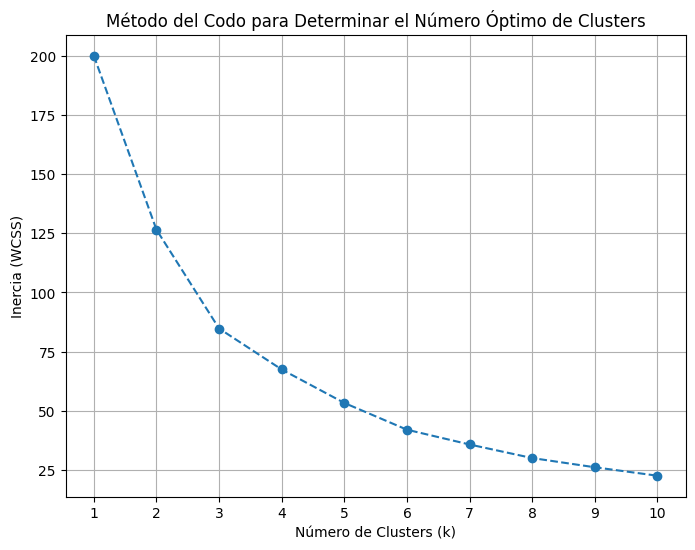

In [ ]:
# Método del Codo para encontrar el número óptimo de clusters
inertia = []
K_range = range(1, 11)  # Probaremos de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k} - Inercia: {kmeans.inertia_}")

# Graficar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Número óptimo de clusters

- En el eje X, tenemos el número de clusters (k).

- En el eje Y, la suma de los errores cuadráticos dentro del cluster (inertia o within-cluster sum of squares, WCSS).

**¿Cómo se interpreta?**

- Inercia alta con pocos clusters: Al inicio (valores pequeños de k), los puntos están agrupados en pocos clusters, así que la inercia es alta.

- La inercia disminuye al aumentar k: Agregar más clusters reduce la distancia de los puntos a sus centroides, por lo tanto, baja la inercia.

- Punto de inflexión = el "codo": Es el punto donde la disminución de la inercia se vuelve menos pronunciada. A partir de ahí, añadir más clusters no mejora significativamente la agrupación.

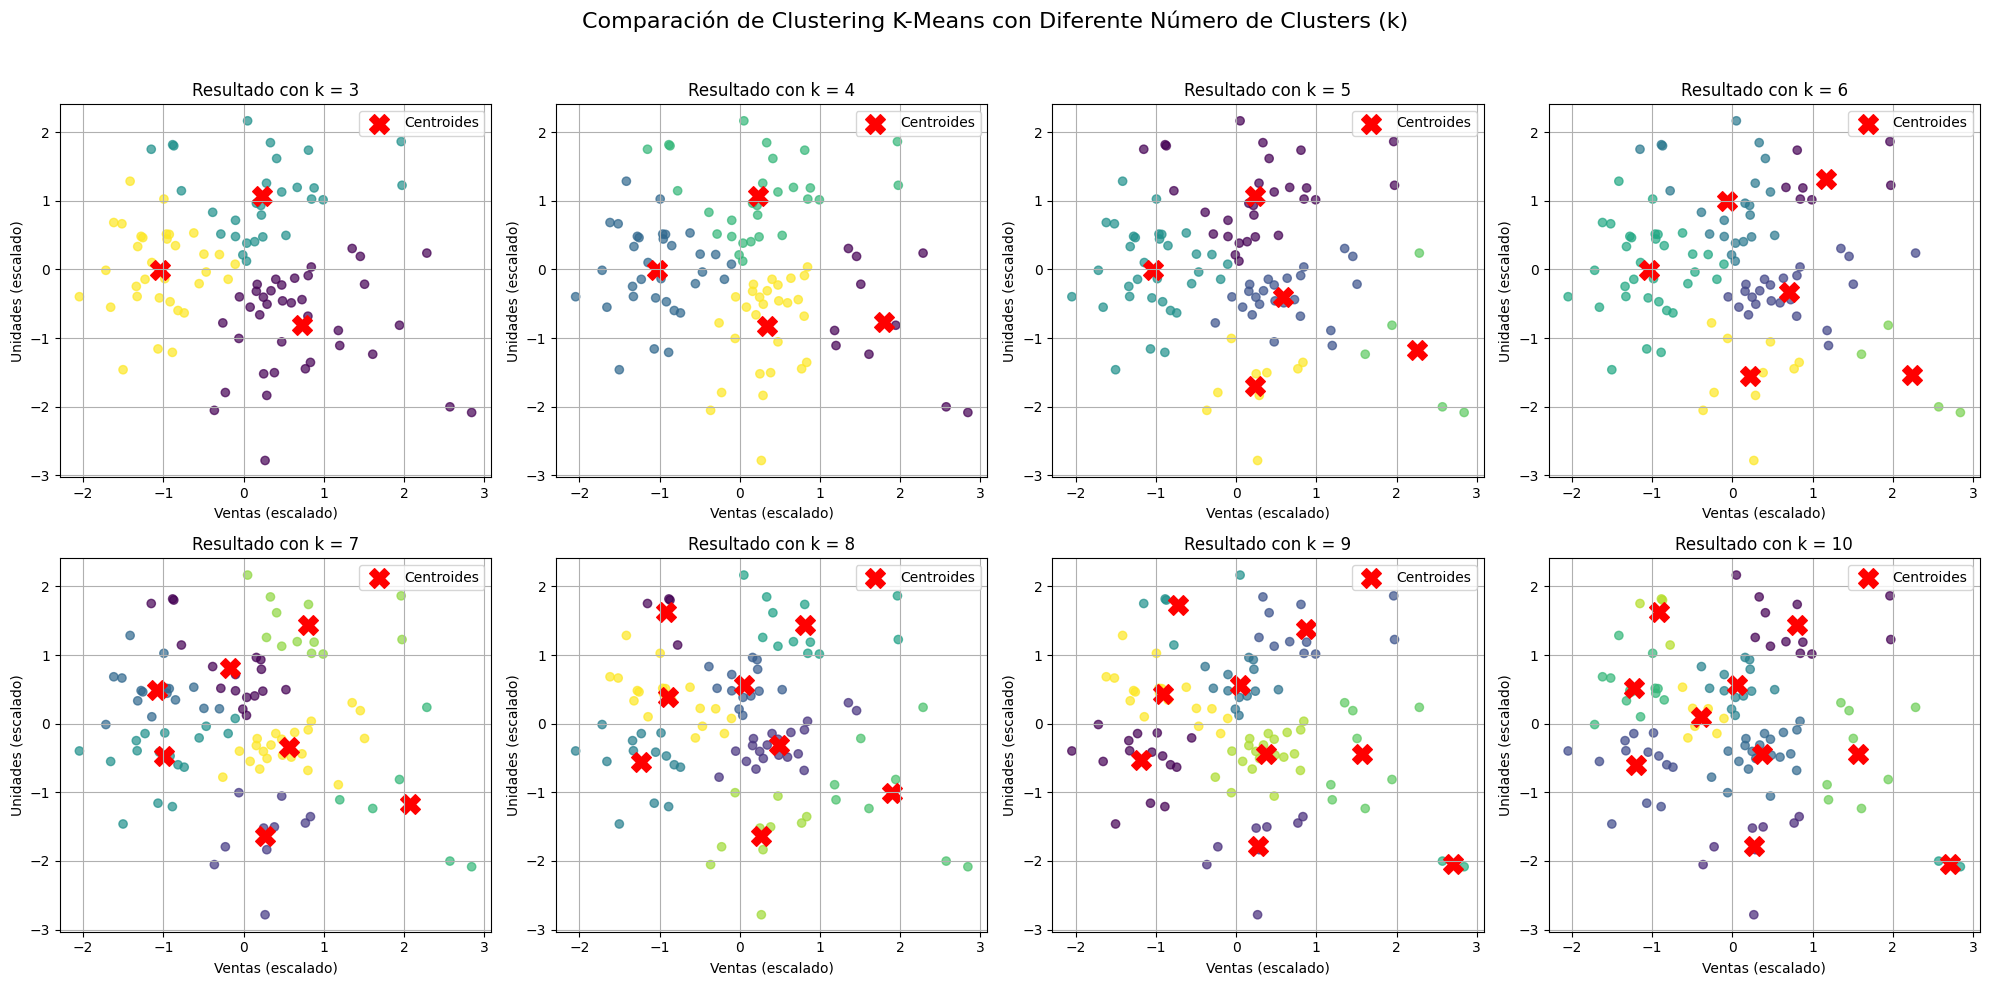

In [ ]:
# Visualizar los resultados para diferentes números de clusters (de 3 a 10)
K_range_to_plot = range(3, 11)
num_plots = len(K_range_to_plot)

# Crear una figura con subplots en una cuadrícula
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

for i, k in enumerate(K_range_to_plot):
    # Entrenar el modelo KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    final_labels = kmeans.labels_
    final_centroids = kmeans.cluster_centers_

    # Graficar el resultado en el subplot correspondiente
    ax = axes[i]
    # Usar un colormap para asignar colores automáticamente
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
    ax.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='X', s=200, label='Centroides')
    ax.set_title(f'Resultado con k = {k}')
    ax.set_xlabel('Ventas (escalado)')
    ax.set_ylabel('Unidades (escalado)')
    ax.legend()
    ax.grid(True)

# Ocultar los ejes no utilizados si el número de plots no es 8
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Comparación de Clustering K-Means con Diferente Número de Clusters (k)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# RESUMEN

**Importancia del Escalado:**

Como vimos en los gráficos, el clustering sobre datos no escalados fue dominado por la variable 'ventas' debido a su mayor magnitud. El escalado de datos con StandardScaler fue crucial para que ambas variables ('unidades' y 'ventas') contribuyeran por igual al cálculo de distancias, resultando en clusters mucho más significativos y balanceados.

**Interpretación de los Clusters:**

- **Cluster 0:** Se caracteriza por tener el menor número de unidades vendidas y las ventas más bajas.
- **Cluster 1: **Representa el segmento con el mayor número de unidades vendidas y las ventas más altas.
- **Cluster 2:** Agrupa a los puntos con un número de unidades y ventas intermedias.

**Uso de Scikit-learn:**

La implementación de K-means con scikit-learn es la forma recomendada y más eficiente. Nos permitió obtener un resultado robusto con muy pocas líneas de código, manejando optimizaciones como n_init automáticamente.

Este clustering nos ha permitido segmentar los datos en tres grupos distintos, lo cual podría ser el primer paso para estrategias de negocio personalizadas para cada segmento.

# Explicación del parámetro `n_init`

El parámetro `n_init` en K-means de scikit-learn determina el número de veces que el algoritmo se ejecutará con diferentes inicializaciones de centroides. K-means es sensible a la elección inicial de los centroides, y una mala inicialización puede llevar a "mínimos locales", es decir, a una solución de clustering que no es la mejor posible.

Al ejecutar el algoritmo múltiples veces (`n_init` > 1) con diferentes centroides aleatorios, scikit-learn puede elegir la mejor de estas ejecuciones (la que tenga la menor inercia o suma de distancias al cuadrado).

-   **`n_init=1`**: El algoritmo se ejecuta una sola vez. Si la inicialización es mala, el resultado puede ser pobre.
-   **`n_init=10` (valor por defecto)**: El algoritmo se ejecuta 10 veces, y se elige el mejor resultado. Esto aumenta significativamente la probabilidad de encontrar una buena solución de clustering.

En este caso, los resultados fueron consistentes con `n_init` de 10, 20 y 30. Esto indica que nuestros clusters son bastante claros y el algoritmo converge a la misma solución estable fácilmente.

